# Week 3 Lab: Data Science Essentials

**Goal**: To master the fundamental Python libraries that power every AI model: **NumPy**, **Pandas**, and **Matplotlib**.

> **Why this lab matters**:
> You cannot build a skyscraper without a foundation. Before we can train Neural Networks (Week 5) or analyze Network Traffic (Midterm), we must know how to handle Data (Week 3).
> *  **NumPy**: The math engine. Standard Python lists are too slow for AI. NumPy makes them fast.
> *  **Pandas**: The excel-replacement. It allows us to load, filter, and clean massive datasets.
> *  **Matplotlib**: The eyes. It allows us to visualize data to understand patterns before we model them.

> **Structure**
> In **Parts 1-3**, we will learn the generic concepts on simple data. In **Part 4**, we will apply all these skills to a real **Network Traffic** dataset, preparing you for the Midterm Project.


---


## Part 1: NumPy (The Math Engine)

In standard Python, if you want to multiply two lists of numbers, you have to write a slow `for` loop. In NumPy, you do it in parallel.
> **Official Documentation**: [NumPy User Guide](https://numpy.org/doc/stable/user/absolute_beginners.html)

#### Theory: Why NumPy?
Python lists are **linked lists**, meaning each element is stored separately in memory. NumPy arrays are **contiguous memory blocks** (like C arrays).

**Key Concept: Vectorization**
Instead of looping through elements one by one, NumPy applies operations to the entire array at once (SIMD).

| Function | Description | Example |
| :--- | :--- | :--- |
| `np.array(list)` | Creates an array | `np.array([1, 2, 3])` |
| `np.arange(n)` | Range from 0 to n-1 | `np.arange(10)` |
| `np.zeros(n)` | Array of zeros | `np.zeros(5)` |
| `arr.shape` | Dimensions of array | `(3, 3)` |
| `arr.mean()` | Average value | `np.mean(arr)` |


### 1.1 Installation & Import


In [ ]:
import numpy as np  # The standard alias


### 1.2 Vectors and Matrices
A **Scalar** is 0D (a single number).
A **Vector** is 1D (a row of numbers).
A **Matrix** is 2D (a grid of numbers).
A **Tensor** is nD (matrix with more dimensions).


In [ ]:
# Creating a Vector
x = np.array([1, 2, 3])
print("Vector:", x)

# Creating a Matrix (2x3)
A = np.array([
[1, 2, 3],
[4, 5, 6]
])
print("Matrix Shape:", A.shape)  # Output: (2, 3)


### 1.3 Broadcasting (The Power)
This is why we use Numpy. We can perform math on entire arrays at once.


In [ ]:
# Standard Python (The Slow Way)
my_list = [1, 2, 3]
new_list = []
for item in my_list:
new_list.append(item * 2)
print("Python List:", new_list)

# NumPy (The Fast Way)
my_arr = np.array([1, 2, 3])
new_arr = my_arr * 2  # Multiplies every element by 2 instantly!
print("Numpy Array:", new_arr)


**Task 1**: Create a NumPy array of numbers from 0 to 9. Multiply the entire array by 10 and subtract 5. Print the result.


In [ ]:
# Write your code here


<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
# Create an array from 0-9
x = np.arange(10)

# Broadcast operation: Multiply by 10 and subtract 5
result = (x * 10) - 5

print(result)
```
</details>


---


## Part 2: Pandas (Data Manipulation)

Real-world data is messy. It comes in CSVs, SQL databases, or Excel sheets. Pandas gives us the **DataFrame**, a powerful programmable spreadsheet.
> **Official Documentation**: [Pandas Getting Started](https://pandas.pydata.org/docs/getting_started/index.html)

#### Cheat Sheet: Common Data Cleaning Functions
Here are the most essential functions you will use to clean datasets.

| Function | Purpose | Usage |
| :--- | :--- | :--- |
| `df.head(n)` | View first n rows | `df.head(5)` |
| `df.info()` | Check data types & non-nulls | `df.info()` |
| `df.describe()` | Statistical summary | `df.describe()` |
| `df.isnull().sum()` | Count missing values | `df.isnull().sum()` |
| `df.dropna()` | Remove rows with NaNs | `df.dropna()` |
| `df.fillna(value)` | Replace NaNs with value | `df['col'].fillna(0)` |
| `df.duplicated()` | specific rows are duplicates | `df[df.duplicated()]` |
| `df.drop_duplicates()` | Remove duplicate rows | `df.drop_duplicates()` |
| `df['col'].astype(type)` | Convert column type | `df['price'].astype(float)` |
| `df['col'].value_counts()` | Count unique values | `df['status'].value_counts()` |

> **Pro Tip**: Always run `.info()` first to spot missing values/wrong types.


### 2.1 Creating a DataFrame


In [ ]:
import pandas as pd

data = {
"Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
"Age": [24, 27, 22, 32, 29],
"Score": [85, 90, 88, 92, 95],
"City": ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix"]
}

df = pd.DataFrame(data)
print(df)


### 2.2 Inspection & Filtering
We rarely read the whole table. We inspect existing data.


In [ ]:
# See the first 5 rows
print("--- Head ---")
print(df.head())

# Get statistical summary (Mean, Max, Min)
print("\n--- Describe ---")
print(df.describe())

# Filter data: Who scored above 90?
print("\n--- High Scorers ---")
high_scorers = df[df["Score"] > 90]
print(high_scorers)


### 2.3 Handling Missing Data
Real data has holes (NaNs). AI models crash if you feed them NaNs. You must **Clean** your data.


In [ ]:
# Simulating missing data
df.loc[2, "Score"] = np.nan  # Charlie lost his score

print(df)

# Strategy 1: Drop the row (If you have lots of data)
df_clean = df.dropna()
print("\nDropped NaNs:\n", df_clean)

# Strategy 2: Fill the hole (Imputation)
# Fill with the average score of everyone else
mean_score = df["Score"].mean()
df["Score"] = df["Score"].fillna(mean_score)
print("\nFilled NaNs:\n", df)


**Task 2**: Create a DataFrame with 5 students. Give one student a `NaN` grade. Use Pandas to fill that `NaN` with the class average.


In [ ]:
# Write your code here


<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
# Create DataFrame with 5 students and 1 NaN
data = {
  "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
  "Grade": [85, 92, np.nan, 88, 95]
}
df_students = pd.DataFrame(data)

# Calculate Mean Grade
mean_grade = df_students["Grade"].mean()

# Fill NaN with Mean
df_students["Grade"] = df_students["Grade"].fillna(mean_grade)

print(df_students)
```
</details>


---


## Part 3: Matplotlib (Visualization)

"A picture is worth a thousand numbers." Never train a model on data you haven't looked at.
> **Official Documentation**: [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/index.html)

#### Theory: Which Plot to Use?
Choosing the right visualization is a skill. Don't just guess.

| Plot Type | Function | Best Use Case |
| :--- | :--- | :--- |
| **Line Plot** | `plt.plot()` | Trends over time (Time Series). |
| **Scatter Plot** | `plt.scatter()` | Correlations between two variables. |
| **Histogram** | `plt.hist()` | Distribution of a single variable. |
| **Bar Chart** | `plt.bar()` | Comparing categories. |


In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)  # 100 numbers from 0 to 10
y = np.sin(x)                # The Sine wave

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Sine Wave', color='blue')
plt.title("My First AI Plot")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


**Task 3**: Create a scatter plot. Generate 50 random x and y numbers using `np.random.rand(50)`. Plot them as red dots.


In [ ]:
# Write your code here


<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
# Generate random data
x = np.random.rand(50)
y = np.random.rand(50)

# Create Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='red', label='Random Points')
plt.title("Random Scatter Plot")
plt.xlabel("X Value")
plt.ylabel("Y Value")
plt.legend()
plt.show()
```
</details>


---


## Part 4: Real-World Data Cleaning (**Network Traffic**)

Now that we know the tools, we will apply them to a **Real-World Network Dataset**.
This dataset (`Week_3_Lab_Data.csv`) mirrors the **Midterm Project** data (PCAP structure).

**Context**:
*  `flow_duration`: How long the connection lasted.
*  `packet_count`: Number of packets transferred.
*  `protocol`: The protocol used (TCP/UDP).


### 4.1 Loading the Dirty Network Dataset


In [32]:
df = pd.read_csv('Week_3_Lab_Data.csv')
print(df.head())
print(df.info())


   flow_duration  packet_count  byte_count protocol       label  \
0        3.69449          67.0       32756      TCP      benign   
1      181.34161        2595.0     2885640      UDP  suspicious   
2        6.05867          30.0       16326      TCP      benign   
3        5.54082          61.0       43414      TCP      benign   
4        0.79929         101.0       54627      UDP      benign   

   packets_per_second  
0             18.1351  
1             14.3100  
2              4.9516  
3             11.0092  
4            126.3629  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   flow_duration       1928 non-null   float64
 1   packet_count        1958 non-null   float64
 2   byte_count          2050 non-null   int64  
 3   protocol            2050 non-null   object 
 4   label               2050 non-null   object 
 5  

---
### 4.2 Handling Missing Values (NaNs)

**Concept**: In network monitoring, sensors might fail to record a specific metric during high load (e.g., passing `NaN` instead of a packet count). AI models cannot handle NaNs algebraically.

**Solution**: We usually **Impute** (fill) the missing values rather than dropping them, to preserve the rest of the flow's data.
*  **Mean/Median**: Good for numerical data.
*  **Mode**: Good for categorical data.


In [33]:
print("Missing before clean:")
print(df.isnull().sum())

# Strategy: Fill missing flow_duration with Mean, packet_count with Median
df['flow_duration'] = df['flow_duration'].fillna(df['flow_duration'].mean())
df['packet_count'] = df['packet_count'].fillna(df['packet_count'].median())

print("\nMissing after clean:")
print(df.isnull().sum())


Missing before clean:
flow_duration         122
packet_count           92
byte_count              0
protocol                0
label                   0
packets_per_second      0
dtype: int64

Missing after clean:
flow_duration         0
packet_count          0
byte_count            0
protocol              0
label                 0
packets_per_second    0
dtype: int64


---
### 4.3 Handling Duplicate Flows

**Concept**: Duplicate rows might occur if two sensors record the same flow, or if the logging system retries an entry. Duplicates bias the AI model, making it memorize common fast flows rather than learning rare attacks.

**Solution**: Remove them completely.


In [34]:
duplicates = df.duplicated().sum()
print(f"Duplicates detected: {duplicates}")

df = df.drop_duplicates()


Duplicates detected: 40


---
### 4.4 Handling Structural Errors (Protocol Normalisation)

**Concept**: Computers treat `TCP`, `tcp`, and `Tcp` as three mutually exclusive protocols. This fractures the data.

**Solution**: **Standardization**. We convert all text to a consistent case (usually Upper Case).


In [35]:
print("Protocols before norm:", df['protocol'].unique())

prot_map ={'udp': 'UDP', 'tcp': 'TCP', 'icmp': 'ICMP','Tcp': 'TCP'}
df['protocol'] = df['protocol'].replace(prot_map)

df['protocol'] = df['protocol'].str.upper()

print("Protocols after norm:", df['protocol'].unique())


Protocols before norm: ['TCP' 'UDP' 'udp' 'Tcp' 'tcp']
Protocols after norm: ['TCP' 'UDP']


---
### 4.5 Handling Outliers & Invalid Traffic Data

**Concept**: Real-world data describes physical impossibilities (e.g., negative time) or extreme anomalies (e.g., a flow lasting 10 years).

**Solution**:
1. **Sanity Check**: Take absolute value of negative numbers.
2. **Clipping/Filtering**: Remove values beyond a reasonable physical threshold.


In [36]:
# Fix negative durations (Physical impossibility)
df['flow_duration'] = df['flow_duration'].abs()

# Remove extreme outliers (e.g., flows > 10,000 seconds)
# In a real IDS, long flows might be valid, but here we treat extreme values as noise.
df = df[df['flow_duration'] < 10000]


---
### 4.6 Feature Engineering

**Concept**: Sometimes the raw columns aren't enough. A DDoS attack might look like normal traffic if you only look at `byte_count`, but if you look at `bytes_per_packet`, you might see tiny empty packets.

**Solution**: Create **Derived Features** that combine existing columns to reveal hidden patterns.


   byte_count  packet_count  bytes_per_packet
0       32756          67.0        488.895522
1     2885640        2595.0       1112.000000
2       16326          30.0        544.200000
3       43414          61.0        711.704918
4       54627         101.0        540.861386

Correlation matrix:
                     flow_duration  packet_count  byte_count  \
flow_duration            1.000000      0.374351    0.388304   
packet_count             0.374351      1.000000    0.963001   
byte_count               0.388304      0.963001    1.000000   
packets_per_second      -0.008264     -0.009909   -0.009998   
bytes_per_packet         0.107557      0.003339    0.254106   
flow_duration_norm       1.000000      0.374351    0.388304   
label_benign            -0.257755     -0.553700   -0.573336   
label_suspicious         0.257755      0.553700    0.573336   
protocol_TCP            -0.250532     -0.592328   -0.606367   
protocol_UDP             0.250532      0.592328    0.606367   

        

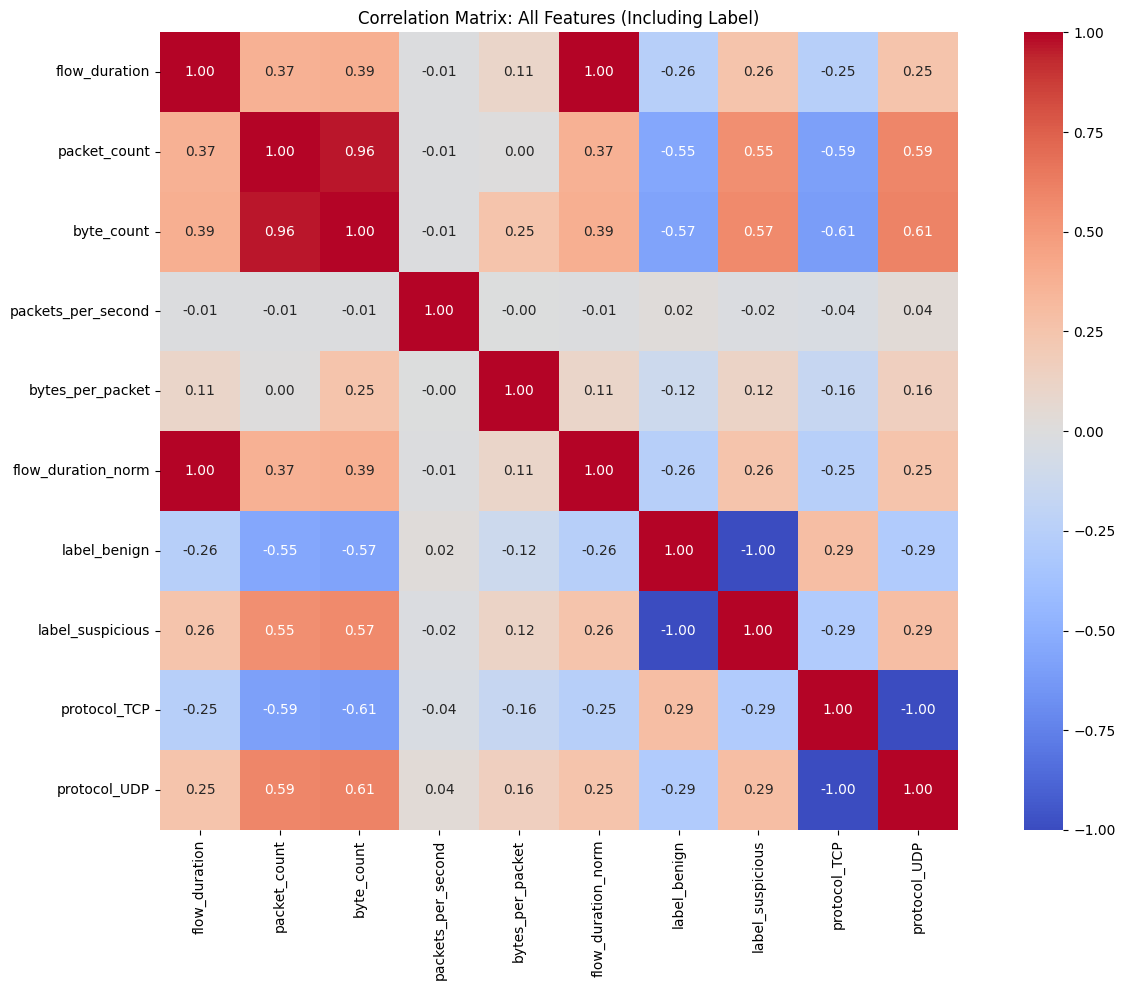

In [52]:
df['bytes_per_packet'] = df['byte_count'] / df['packet_count']

print(df[['byte_count', 'packet_count', 'bytes_per_packet']].head())

# Feature Selection via Correlation Analysis
# Now that we have engineered features, let's analyze correlations for feature selection

# First, encode categorical columns (label, protocol) to numerical
df_corr = df.copy()
df_corr = pd.get_dummies(df_corr, columns=['label', 'protocol'], drop_first=False)

# Compute correlation matrix for all columns including encoded labels
corr = df_corr.corr(numeric_only=True)
print("\nCorrelation matrix:\n", corr)

# Visualize using seaborn heatmap
import seaborn as sns
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', cbar=True, fmt='.2f', square=True)
plt.title("Correlation Matrix: All Features (Including Label)")
plt.tight_layout()
plt.show()

### 4.6.1 Feature Selection Analysis for IDS Machine Learning

Correlation is vital for feature selection. The graph above evaluates the correlation between network features and the `label_suspicious` target to optimize a Machine Learning model for an Intrusion Detection System (IDS).
Let us see how you can select the best features from this data, to use for training your future ML model.

---

#### 4.6.1.1. Top Predictive Features
The following features show the strongest linear relationship with the `label_suspicious` target and should be prioritized for the final training set:

* **`byte_count` (Correlation: 0.57):** The strongest individual predictor. High volume traffic is a major indicator of suspicious activity in this dataset.
* **`packet_count` (Correlation: 0.55):** A strong predictor, though highly redundant with `byte_count` (0.96 correlation). 
* **`protocol_UDP` (Correlation: 0.29):** Indicates that suspicious activity is more likely to use the UDP protocol in this specific environment.
* **`flow_duration` (Correlation: 0.26):** Provides necessary temporal context for identifying long-running or extremely short-lived attacks.

---

#### 4.6.1.2. Redundancy & Multicollinearity (Drop List)
To improve model efficiency and prevent overfitting, the following features should be excluded:

| Feature to Drop | Reason |
| :--- | :--- |
| **`flow_duration_norm`** | 1.00 correlation with `flow_duration`. It adds zero new information. |
| **`label_benign`** | -1.00 correlation with `label_suspicious`. Only one target label is needed for binary classification. |
| **`packet_count`** | (Optional) Highly redundant (0.96) with `byte_count`. Drop if using linear models to avoid instability. |

---

#### 4.6.1.3. Low-Impact Features
These features provide unique data (low correlation with other features) but show little to no relationship with the target labels in this dataset:

* **`packets_per_second` (Correlation: -0.02):** Statistically insignificant for this specific classification task.
* **`avg_bytes_per_packet` (Correlation: 0.12):** Provides a very weak signal and should only be kept if the model has high capacity (e.g., Deep Learning or Gradient Boosting).

---

#### 4.6.1.4. Final Recommended Feature Set
For a lean, high-performing IDS model, extract these features:

1.  **`byte_count`**
2.  **`protocol_UDP`**
3.  **`flow_duration`**
4.  **`protocol_TCP`** (Included to provide the inverse context of UDP)

---

#### 4.6.1.5. Correlation Summary Table

| Feature | Correlation with Suspicious Label | Action |
| :--- | :--- | :--- |
| **byte_count** | 0.57 | **Keep** |
| **packet_count** | 0.55 | **Drop/Optional** |
| **protocol_UDP** | 0.29 | **Keep** |
| **flow_duration** | 0.26 | **Keep** |
| **avg_bytes_per_packet**| 0.12 | **Low Priority** |
| **packets_per_second** | -0.02 | **Discard** |

**Task 4**
Fix protocol inconsistencies, fill missing `packet_count` with the median, and remove negative `flow_duration` values.


In [ ]:
# Write your code here


<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
# Load Data
df = pd.read_csv("Week_3_Lab_Data.csv")

# 1. Fix Protocol (Standardize to Upper Case)
df['protocol'] = df['protocol'].str.upper()

# 2. Fill Missing Packet Count (Median)
median_packets = df['packet_count'].median()
df['packet_count'] = df['packet_count'].fillna(median_packets)

# 3. Remove Negative Flow Duration
df = df[df['flow_duration'] >= 0]

print(df.info())
```
</details>


---
### 4.7 Visualizing Traffic Patterns

**Concept**: Before rigorous math (Normalization), use your eyes. Visualization confirms if our cleaning worked and reveals the data's shape.

**Solution**: Use a **Scatter Plot** to check the relationship between Packet Count and Byte Count.


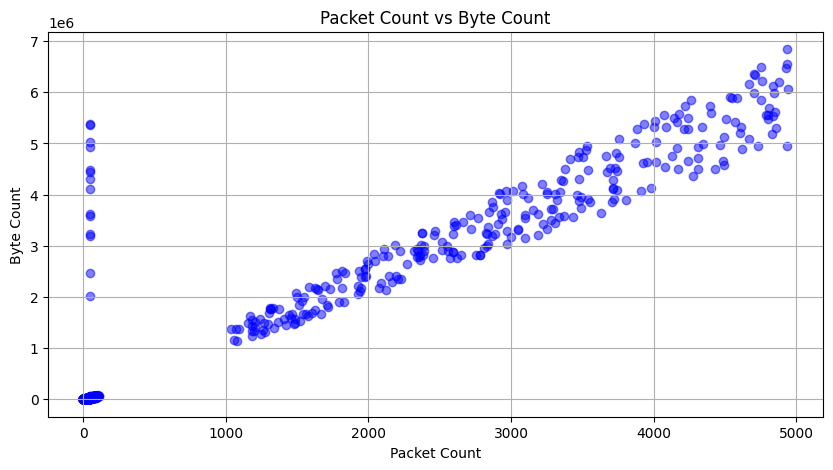

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(df['packet_count'], df['byte_count'], alpha=0.5, c='blue')
plt.title("Packet Count vs Byte Count")
plt.xlabel("Packet Count")
plt.ylabel("Byte Count")
plt.grid(True)
plt.show()


> **Observation**: A linear trend is expected. If we saw a cluster of points with High Packets but Zero Bytes, that would be an anomaly.


The scatter plot shows a strong linear relationship between packet count and byte count for most flows, indicating normal traffic behavior with consistent packet sizes. However, several outliers exist where flows have very few packets but unusually high byte counts, which may represent anomalous or potentially malicious activity. These deviations from the normal traffic pattern are useful indicators for intrusion detection models.

The correlation analysis shows a strong positive relationship (r = 0.963) between packet count and byte count. This indicates that network flows generally contain packets of consistent size, resulting in a proportional increase in byte count as the number of packets increases. Such behavior is typical of normal network traffic patterns. However, deviations from this relationship may indicate anomalous or potentially malicious activity, making these features useful for intrusion detection models.

---

### 4.8 Preprocessing for AI Models

Before feeding data into an AI model, we must transform it into a format the model understands. The two most critical steps are **Normalization** and **Encoding**.


#### A. Normalization (Scaling)

**Concept**: AI models are sensitive to the scale of numbers. If `packet_count` ranges from 0-1000 and `flow_duration` ranges from 0-1 (seconds), the model might think `packet_count` is 1000x more important.

**Solution**: We scale all numerical features to fall between **0 and 1**.
$$ X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}} $$


In [39]:
# Example: Normalize 'flow_duration'
min_val = df['flow_duration'].min()
max_val = df['flow_duration'].max()

df['flow_duration_norm'] = (df['flow_duration'] - min_val) / (max_val - min_val)

print(df[['flow_duration', 'flow_duration_norm']].head())


   flow_duration  flow_duration_norm
0        3.69449            0.001483
1      181.34161            0.072776
2        6.05867            0.002431
3        5.54082            0.002224
4        0.79929            0.000321


#### B. Encoding (Text to Numbers)

**Concept**: AI models (like Neural Networks) cannot understand text like "TCP" or "UDP". They only understand numbers.

**Solution**: We use **One-Hot Encoding**. Instead of one column `protocol` with text, we create binary columns:
*  `protocol_TCP`: 1 if TCP, 0 otherwise.
*  `protocol_UDP`: 1 if UDP, 0 otherwise.


In [50]:
# One-Hot Encoding using Pandas
df_encoded = pd.get_dummies(df, columns=['protocol','label'], prefix=['proto','label'])

print(df_encoded.head())
# Notice the new columns: proto_TCP, proto_UDP


   flow_duration  packet_count  byte_count  packets_per_second  \
0        3.69449          67.0       32756             18.1351   
1      181.34161        2595.0     2885640             14.3100   
2        6.05867          30.0       16326              4.9516   
3        5.54082          61.0       43414             11.0092   
4        0.79929         101.0       54627            126.3629   

   bytes_per_packet  flow_duration_norm  proto_TCP  proto_UDP  label_benign  \
0        488.895522            0.001483       True      False          True   
1       1112.000000            0.072776      False       True         False   
2        544.200000            0.002431       True      False          True   
3        711.704918            0.002224       True      False          True   
4        540.861386            0.000321      False       True          True   

   label_suspicious  
0             False  
1              True  
2             False  
3             False  
4             Fals

Correlation matrix:
                     flow_duration  packet_count  byte_count  \
flow_duration            1.000000      0.374351    0.388304   
packet_count             0.374351      1.000000    0.963001   
byte_count               0.388304      0.963001    1.000000   
packets_per_second      -0.008264     -0.009909   -0.009998   
bytes_per_packet         0.107557      0.003339    0.254106   
flow_duration_norm       1.000000      0.374351    0.388304   
label_benign            -0.257755     -0.553700   -0.573336   
label_suspicious         0.257755      0.553700    0.573336   
protocol_TCP            -0.250532     -0.592328   -0.606367   
protocol_UDP             0.250532      0.592328    0.606367   

                    packets_per_second  bytes_per_packet  flow_duration_norm  \
flow_duration                -0.008264          0.107557            1.000000   
packet_count                 -0.009909          0.003339            0.374351   
byte_count                   -0.009998       

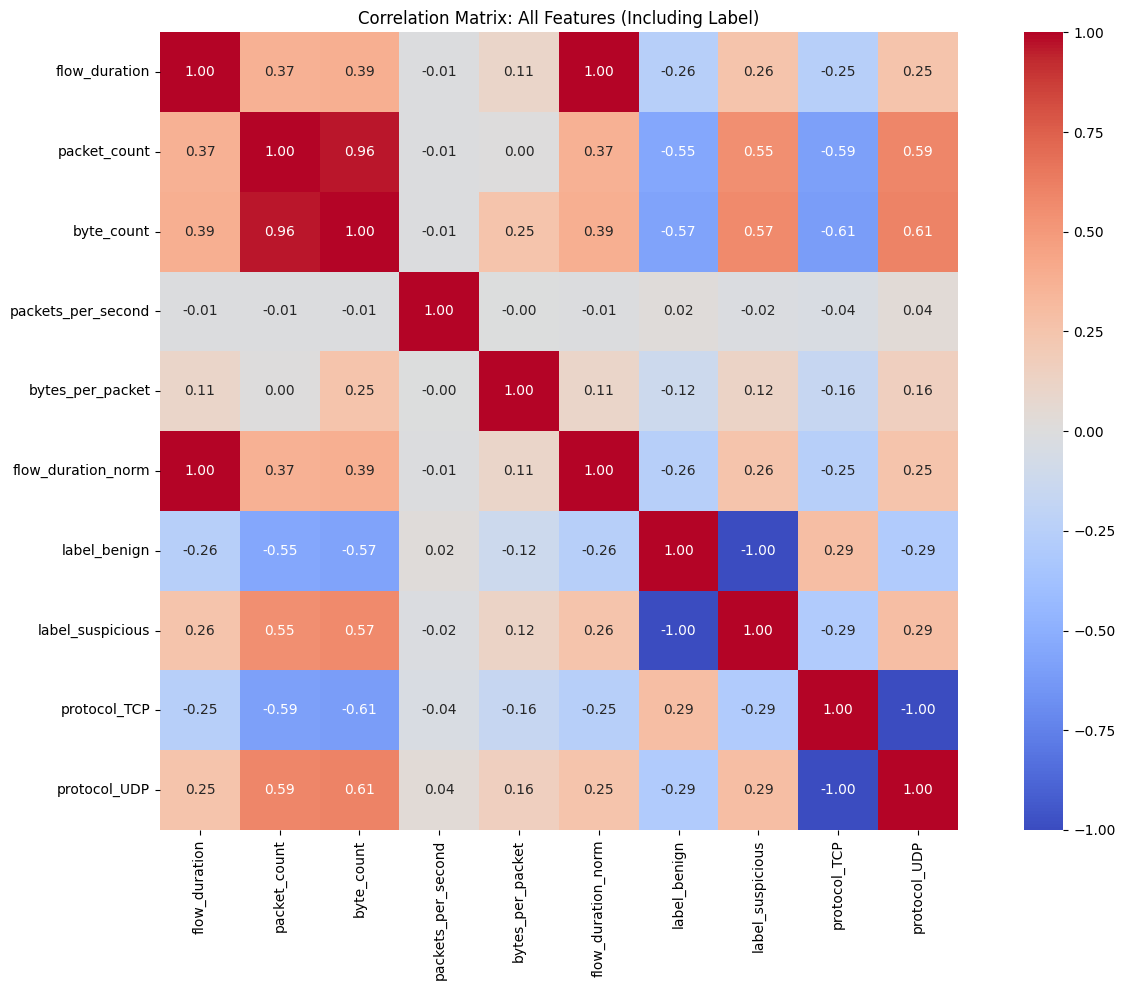

In [ ]:
# Write your code here

**Task 5**: Normalize the `byte_count` column. Then, One-Hot Encode the `protocol` column (if you haven't already). print the new dataframe's columns.

<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
# 1. Normalize Byte Count (Min-Max)
df['byte_count_norm'] = (df['byte_count'] - df['byte_count'].min()) / (df['byte_count'].max() - df['byte_count'].min())

# 2. One-Hot Encode Protocol (Pandas get_dummies)
df = pd.get_dummies(df, columns=['protocol'], prefix='proto')

print(df_encoded.head())
print("Columns:", df.columns)
```
</details>


---

### Reflection Question

Why is data cleaning and feature engineering **even more critical** when working with data extracted directly from **PCAP files**?

---


## Summary

You now possess the **Data Science Triad**:
1. **NumPy** – Math.
2. **Pandas** – Data.
3. **Matplotlib** – Visualization.

You have also successfully cleaned a **Network Traffic Dataset**, preparing you for the **Midterm Project**.
